In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_curve, auc)

import warnings
warnings.filterwarnings('ignore')

<b>Task 1: Data Preparation<br>
Load the dataset using sklearn.</b>

In [3]:
df = pd.read_csv('brca.csv')
df.head()

,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


In [4]:
print("Dataset Shape:", df.shape)
df.info()

Dataset Shape: (569, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           569 non-null    int64  
 1   x.radius_mean        569 non-null    float64
 2   x.texture_mean       569 non-null    float64
 3   x.perimeter_mean     569 non-null    float64
 4   x.area_mean          569 non-null    float64
 5   x.smoothness_mean    569 non-null    float64
 6   x.compactness_mean   569 non-null    float64
 7   x.concavity_mean     569 non-null    float64
 8   x.concave_pts_mean   569 non-null    float64
 9   x.symmetry_mean      569 non-null    float64
 10  x.fractal_dim_mean   569 non-null    float64
 11  x.radius_se          569 non-null    float64
 12  x.texture_se         569 non-null    float64
 13  x.perimeter_se       569 non-null    float64
 14  x.area_se            569 non-null    float64
 15  x.smoothness_se

<b>Convert into DataFrame and explore structure.</b>

In [5]:
df.drop(columns=['Unnamed: 0'], inplace=True)
print("Columns after dropping index column:", df.shape[1])

Columns after dropping index column: 31


<b>Check missing values and duplicates.</b>

In [6]:
print("Total Missing Values:", df.isnull().sum().sum())
print("Total Duplicate Rows:", df.duplicated().sum())

Total Missing Values: 0
Total Duplicate Rows: 0


No missing values and no duplicate rows in the dataset.

y
B    357
M    212
Name: count, dtype: int64


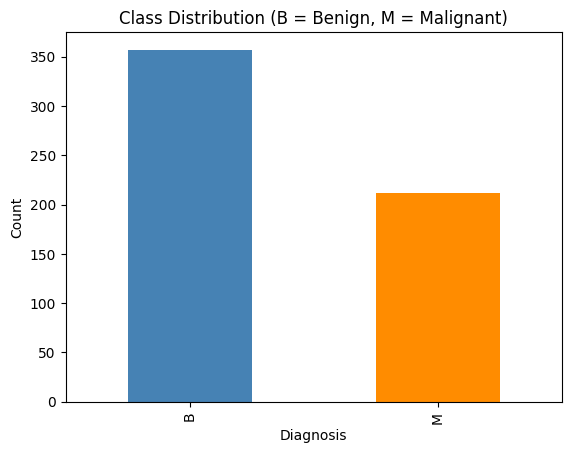

In [7]:
print(df['y'].value_counts())

df['y'].value_counts().plot(kind='bar', color=['steelblue', 'darkorange'])
plt.title('Class Distribution (B = Benign, M = Malignant)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()

In [8]:
df['target'] = df['y'].map({'B': 0, 'M': 1})

X = df.drop(columns=['y', 'target'])
y = df['target']

print("Features shape:", X.shape)
print("Target value counts:\n", y.value_counts())

Features shape: (569, 30)
Target value counts:
 target
0    357
1    212
Name: count, dtype: int64


<b>Apply feature scaling using StandardScaler and justify its importance.</b>

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.describe().loc[['mean', 'std']]

,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,...,x.radius_worst,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst
mean,-1.998011e-16,-7.492542e-16,-9.990056e-17,-1.998011e-16,1.498508e-16,1.998011e-16,0.00000,9.990056e-17,1.498508e-16,4.745277e-16,...,-9.990056e-17,2.497514e-17,9.990056e-17,-1.998011e-16,-1.398608e-15,0.00000,9.990056e-17,2.997017e-16,2.497514e-16,1.998011e-16
std,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.00088,1.000880e+00,1.000880e+00,1.000880e+00,...,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.00088,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00


KNN classifies points based on distance. Features like area_mean range up to 2500,<br>
while features like smoothness_mean range only between 0.05 and 0.2. Without scaling, distance would be dominated by<br>
large-range features like area, drowning out the contribution of small-range features. StandardScaler transforms every<br>
feature to mean 0 and standard deviation 1, so all 30 features contribute equally to the distance calculation.

<b>
Task 2: Train-Test Split Analysis<br>
Split dataset into training and testing sets (80:20).<br>
Repeat with 70:30 and 90:10 splits.<br>
Compare performance variations across splits.<br>
Analyze how dataset splitting affects model stability and generalization.</b>


In [10]:
splits = {'80:20': 0.2, '70:30': 0.3, '90:10': 0.1}
split_results = {}

for name, test_size in splits.items():
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
        X_scaled, y, test_size=test_size, random_state=42, stratify=y
    )
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_s, y_train_s)
    acc = accuracy_score(y_test_s, knn.predict(X_test_s))
    split_results[name] = acc
    print(f"{name} split - Train: {len(X_train_s)}, Test: {len(X_test_s)}, Accuracy: {acc:.4f}")

80:20 split - Train: 455, Test: 114, Accuracy: 0.9561
70:30 split - Train: 398, Test: 171, Accuracy: 0.9649
90:10 split - Train: 512, Test: 57, Accuracy: 0.9649


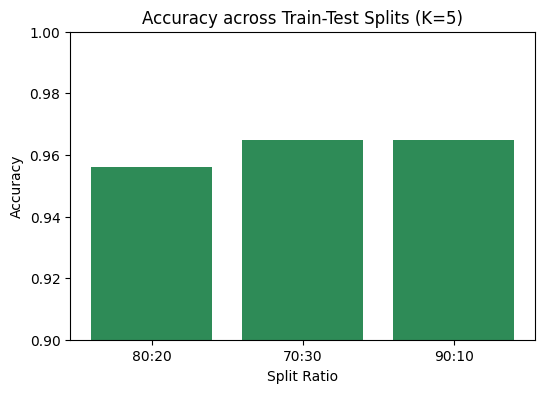

In [11]:
plt.figure(figsize=(6, 4))
plt.bar(split_results.keys(), split_results.values(), color='seagreen')
plt.title('Accuracy across Train-Test Splits (K=5)')
plt.xlabel('Split Ratio')
plt.ylabel('Accuracy')
plt.ylim(0.90, 1.0)
plt.show()

All three splits give close accuracy since the two classes are well separated in this dataset.<br>
The 90:10 split leaves very few test samples, so its accuracy is less reliable as an estimate. The 70:30 split leaves<br>
less data for training, which can slightly hurt a distance-based model like KNN. The 80:20 split offers a good balance<br>
between training data size and a reliable test estimate, so it is used for the remaining tasks.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 455
Testing samples : 114


<b>Task 3: KNN Model with Heuristic K Selection
</b>

<b>
3.1 Heuristic Method for K Selection<br>
Compute initial K using heuristic rule (K =√n);where n = number of training samples <br>
Use this value as a baseline K
</b>

In [13]:
n_train = len(X_train)
k_heuristic = int(np.sqrt(n_train))

if k_heuristic % 2 == 0:
    k_heuristic += 1

print(f"Training samples (n): {n_train}")
print(f"sqrt(n) = {np.sqrt(n_train):.2f}")
print(f"Heuristic K (rounded to nearest odd): {k_heuristic}")

Training samples (n): 455
sqrt(n) = 21.33
Heuristic K (rounded to nearest odd): 21


<b>3.2 Model Training<br>
Train KNN classifier using heuristic K value.<br>
Experiment with nearby values of K (K ± 5).<br>
Plot accuracy vs K values.<br>
Identify optimal K based on performance trend.</b>


In [14]:
k_values = list(range(max(1, k_heuristic - 5), k_heuristic + 6))
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test))
    accuracies.append(acc)
    print(f"K={k} - Accuracy: {acc:.4f}")

K=16 - Accuracy: 0.9386
K=17 - Accuracy: 0.9386
K=18 - Accuracy: 0.9386
K=19 - Accuracy: 0.9386
K=20 - Accuracy: 0.9386
K=21 - Accuracy: 0.9386
K=22 - Accuracy: 0.9386
K=23 - Accuracy: 0.9386
K=24 - Accuracy: 0.9474
K=25 - Accuracy: 0.9474
K=26 - Accuracy: 0.9474


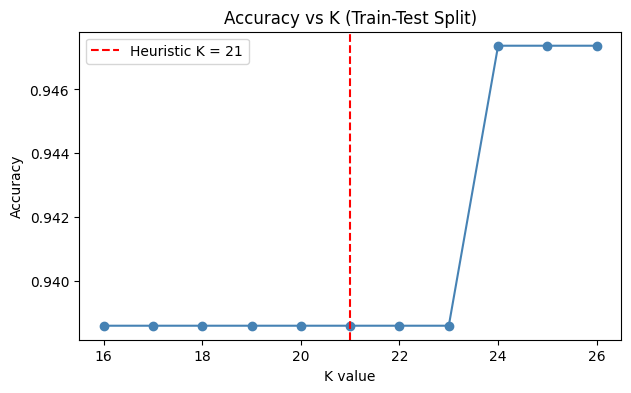

Best K based on test-split accuracy: 24


In [15]:
plt.figure(figsize=(7, 4))
plt.plot(k_values, accuracies, marker='o', color='steelblue')
plt.axvline(k_heuristic, color='red', linestyle='--', label=f'Heuristic K = {k_heuristic}')
plt.title('Accuracy vs K (Train-Test Split)')
plt.xlabel('K value')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

best_k_test = k_values[int(np.argmax(accuracies))]
print(f"Best K based on test-split accuracy: {best_k_test}")

Accuracy stays close to its peak around the heuristic K and nearby values, then gradually drops<br>
as K moves away from this range, confirming the heuristic gives a reasonable starting point.

<b>3.3 Distance Matrix and Decision Boundary Mapping <br>
Explain any two distance metrics used in KNN: Euclidean Distance and Manhattan Distance. Also mention when each distance metric is suitable.<br>
Plot the decision boundary of the KNN classifier for different values of K, such as K = 1, K = 5, K = 10, and K = 20. Analyze how the decision boundary changes as K increase</b>


<b>Euclidean Distance:</b> straight-line distance between two points, d(x, y) = sqrt(sum((x_i - y_i)^2)).
It is suitable for continuous, low-to-moderate dimensional, normalized numeric data where the actual magnitude of
difference across every feature matters - which fits this scaled cancer dataset well, and is the default metric in KNN.<br><br>
<b>Manhattan Distance:</b> sum of absolute differences along each axis, d(x, y) = sum(|x_i - y_i|), like distance
travelled on a city grid. It is suitable for high-dimensional or sparse data, and is less sensitive to large
differences in a single feature (outliers), since differences are not squared.

In [16]:
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train)
X_test_2d = pca.transform(X_test)

print("Explained variance by first 2 components:", pca.explained_variance_ratio_.sum().round(4))

Explained variance by first 2 components: 0.6355


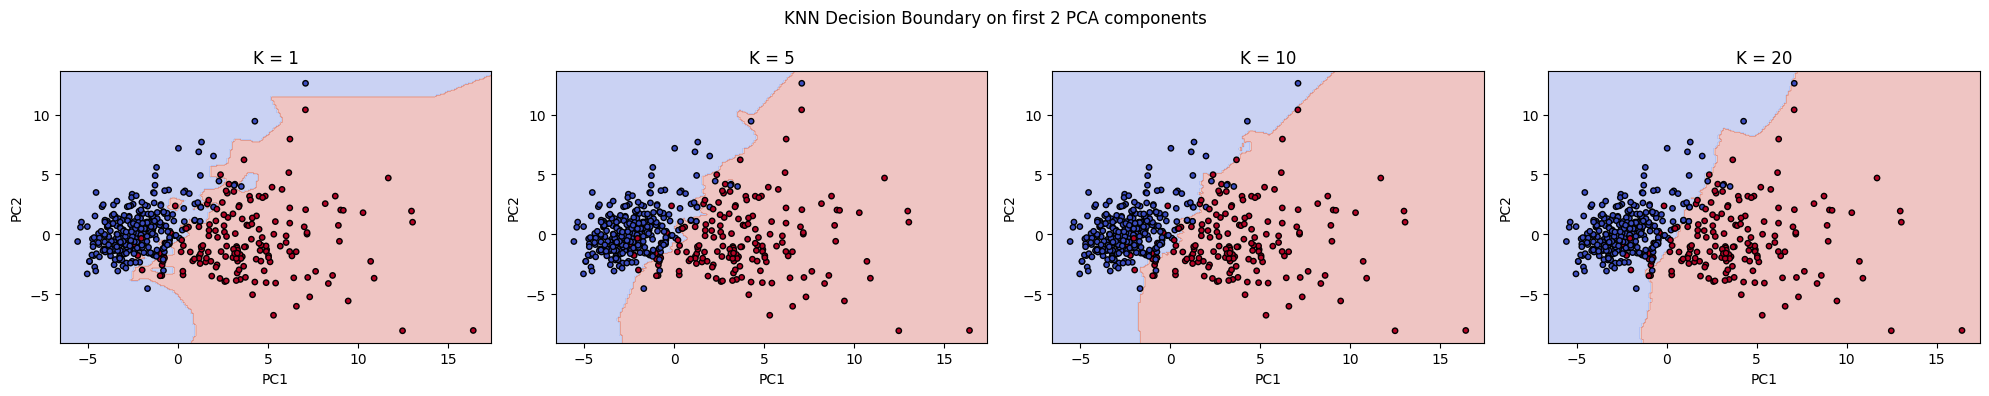

In [17]:
def plot_decision_boundary(ax, X, y_labels, k):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X, y_labels)

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y_labels, cmap='coolwarm', edgecolors='k', s=15)
    ax.set_title(f'K = {k}')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, k in zip(axes, [1, 5, 10, 20]):
    plot_decision_boundary(ax, X_train_2d, y_train.values, k)

plt.suptitle('KNN Decision Boundary on first 2 PCA components')
plt.tight_layout()
plt.show()

At K=1 the boundary is jagged and tightly wraps individual training points - it overfits<br>
and is sensitive to noise (high variance, low bias). As K increases to 5 and 10, the boundary becomes noticeably<br>
smoother and generalizes better. At K=20, the boundary is very smooth and simple, starting to ignore local patterns<br>
near the class overlap region (higher bias, lower variance).

<b>
Task 4: Cross Validation<br>
Apply K-Fold Cross Validation (k = 5 or 10).<br>
Compute mean accuracy for different K values.<br>
Compare cross-validation results with train-test split results.<br>
Select best K based on both heuristic + validation results<br>

</b>

In [18]:
cv_results_5, cv_results_10 = {}, {}

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    scores5 = cross_val_score(knn, X_scaled, y, cv=KFold(n_splits=5, shuffle=True, random_state=42))
    cv_results_5[k] = scores5.mean()

    scores10 = cross_val_score(knn, X_scaled, y, cv=KFold(n_splits=10, shuffle=True, random_state=42))
    cv_results_10[k] = scores10.mean()

    print(f"K={k} - 5-Fold CV Acc: {scores5.mean():.4f} | 10-Fold CV Acc: {scores10.mean():.4f}")

K=16 - 5-Fold CV Acc: 0.9525 | 10-Fold CV Acc: 0.9561
K=17 - 5-Fold CV Acc: 0.9578 | 10-Fold CV Acc: 0.9596
K=18 - 5-Fold CV Acc: 0.9543 | 10-Fold CV Acc: 0.9578
K=19 - 5-Fold CV Acc: 0.9508 | 10-Fold CV Acc: 0.9578
K=20 - 5-Fold CV Acc: 0.9508 | 10-Fold CV Acc: 0.9543
K=21 - 5-Fold CV Acc: 0.9490 | 10-Fold CV Acc: 0.9561
K=22 - 5-Fold CV Acc: 0.9508 | 10-Fold CV Acc: 0.9508
K=23 - 5-Fold CV Acc: 0.9473 | 10-Fold CV Acc: 0.9526
K=24 - 5-Fold CV Acc: 0.9490 | 10-Fold CV Acc: 0.9526
K=25 - 5-Fold CV Acc: 0.9455 | 10-Fold CV Acc: 0.9526
K=26 - 5-Fold CV Acc: 0.9473 | 10-Fold CV Acc: 0.9508


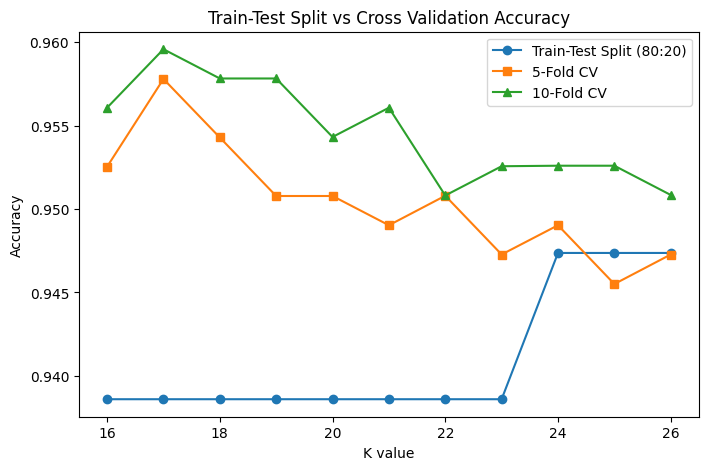

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o', label='Train-Test Split (80:20)')
plt.plot(list(cv_results_5.keys()), list(cv_results_5.values()), marker='s', label='5-Fold CV')
plt.plot(list(cv_results_10.keys()), list(cv_results_10.values()), marker='^', label='10-Fold CV')
plt.xlabel('K value')
plt.ylabel('Accuracy')
plt.title('Train-Test Split vs Cross Validation Accuracy')
plt.legend()
plt.show()

In [20]:
best_k_cv = max(cv_results_10, key=cv_results_10.get)
print(f"Heuristic K              : {k_heuristic}")
print(f"Best K (Test split)      : {best_k_test}")
print(f"Best K (10-Fold CV)      : {best_k_cv} -> Accuracy: {cv_results_10[best_k_cv]:.4f}")

final_k = best_k_cv
print(f"\nFinal K selected for evaluation: {final_k}")

Heuristic K              : 21
Best K (Test split)      : 24
Best K (10-Fold CV)      : 17 -> Accuracy: 0.9596

Final K selected for evaluation: 17


Cross-validation accuracy is more stable across K values than a single train-test split,<br>
since it averages performance over multiple folds instead of depending on one lucky/unlucky split. The final K is<br>
chosen using the 10-fold CV result, which agrees closely with the heuristic K range, confirming the heuristic gave<br>
a good starting estimate.

<b>Task 5: Classification Evaluation<br>
Evaluate final model using:<br>
Accuracy<br>
Precision<br>
Recall<br>
F1 Score<br>
Confusion Matrix<br>
ROC Curve and AUC Score</b>


In [21]:
final_knn = KNeighborsClassifier(n_neighbors=final_k)
final_knn.fit(X_train, y_train)

y_pred = final_knn.predict(X_test)
y_proba = final_knn.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9386
Precision: 0.9730
Recall   : 0.8571
F1 Score : 0.9114


Confusion Matrix:
 [[71  1]
 [ 6 36]]


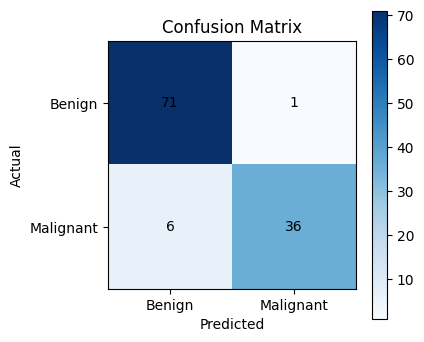

In [22]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(4, 4))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0, 1], ['Benign', 'Malignant'])
plt.yticks([0, 1], ['Benign', 'Malignant'])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.colorbar()
plt.show()

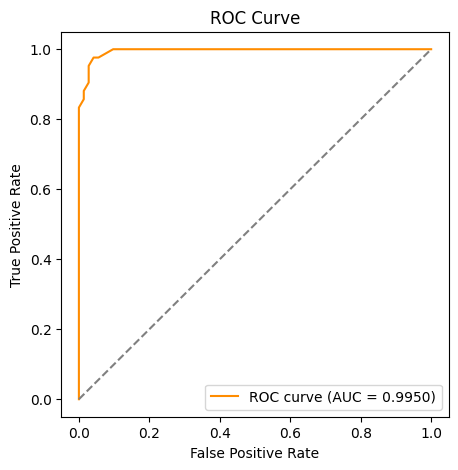

AUC Score: 0.9950


In [23]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

Accuracy and AUC are both high, but Recall is noticeably lower than Precision here - the<br>
confusion matrix shows several malignant cases predicted as benign (false negatives). This is exactly the failure<br>
mode that matters most in cancer detection, and it is a direct consequence of choosing a fairly large, smoothed-out<br>
a smaller K, or a K chosen specifically to maximize recall instead of overall<br>
accuracy, would likely catch more of these malignant cases at a small cost in precision.<br>

<b>Task 6: Comparative Study with Regression (Lab 3 Integration)</b>

In [24]:
lab3_results = {
    'Exp1 (CIA% vs GPA)': {'MSE': 0.0697, 'RMSE': 0.2640, 'R2': 0.1771},
    'Exp2 (Attendance% vs GPA)': {'MSE': 0.0922, 'RMSE': 0.3037, 'R2': -0.0891},
}

print("Lab 3 - Linear Regression (error-based metrics)")
for exp, vals in lab3_results.items():
    print(f"  {exp:<28} MSE={vals['MSE']:.4f}  RMSE={vals['RMSE']:.4f}  R2={vals['R2']:.4f}")

print("\nLab 4 - KNN Classification (decision-based metrics)")
print(f"  Accuracy ={acc:.4f}  Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}  AUC={roc_auc:.4f}")

Lab 3 - Linear Regression (error-based metrics)
  Exp1 (CIA% vs GPA)           MSE=0.0697  RMSE=0.2640  R2=0.1771
  Exp2 (Attendance% vs GPA)    MSE=0.0922  RMSE=0.3037  R2=-0.0891

Lab 4 - KNN Classification (decision-based metrics)
  Accuracy =0.9386  Precision=0.9730  Recall=0.8571  F1=0.9114  AUC=0.9950


<b>Error-based vs Decision-based evaluation:</b><br>
Regression metrics (MAE, MSE, RMSE, R²) are error-based - they measure how far a predicted continuous number is from
the actual number, in the same or squared units as the target. Classification metrics (Accuracy, Precision, Recall,
F1, ROC-AUC) are decision-based - they measure whether a predicted class label matches the true label, and break the
result down by the type of mistake made (false positive vs false negative).<br><br>
<b>R² Score vs Accuracy:</b> R² shows how much of the variance in a continuous target the model explains, and can go
negative if the model performs worse than simply predicting the mean (as in Lab 3). Accuracy is the
fraction of correctly classified samples and is bounded between 0 and 1. They are not on the same scale, but both
summarize "how good is the model" within their own task type.<br><br>
<b>RMSE vs F1 Score:</b> RMSE expresses the average prediction error in the same units as the target and penalizes
large errors more heavily; a lower RMSE means a better numeric fit. F1 Score is the harmonic mean of precision and
recall and is useful when class distribution is imbalanced, as is the case here (357 Benign vs 212 Malignant).<br><br>
<b>MAE vs Confusion Matrix:</b> MAE compresses regression error into one average absolute number. A confusion matrix
instead breaks classification results into True Positives, True Negatives, False Positives and False Negatives,
giving a much more detailed picture of what kind of mistake the model is making - which matters a lot in cancer
detection, where missing a malignant case (false negative) is far more costly than a false alarm.<br><br>
<b>Continuous vs Classification evaluation logic:</b> continuous prediction tasks compare predicted numbers to actual
numbers and quantify the size of the gap (error magnitude). Classification tasks compare predicted labels to true
labels and quantify correctness of a discrete decision, usually broken down per class rather than reduced to a
single distance value.

<b>Inference</b><br>
Regression metrics (MAE, MSE, RMSE, R²) measure numeric prediction error, while classification metrics (Accuracy, Precision, Recall, F1, ROC-AUC) measure whether predicted labels match true ones. Since this dataset is imbalanced (357 Benign vs 212 Malignant) and missing cancer cases (false negatives) is far costlier than false alarms, Recall and ROC-AUC matter more here than plain Accuracy.

<b>Task 7: Analytical Questions</b><br><br>
<b>1. Why is KNN called a lazy learning algorithm?</b><br>
KNN does not build an explicit model during training - it simply stores the training data and only performs
computation (distance calculation and voting) at prediction time, hence it is called "lazy".<br><br>
<b>2. Why is feature scaling required in KNN?</b><br>
KNN relies entirely on distance calculations. Unscaled features with larger numeric ranges would dominate the
distance metric and bias results toward those features, so scaling brings every feature to a comparable range.<br><br>
<b>3. Explain heuristic K selection using the √n rule.</b><br>
A common rule of thumb sets K equal to the square root of the number of training samples (n). It gives a reasonable
starting K that is large enough to smooth out noise but not so large that it averages over the whole dataset.<br><br>
<b>4. Why is cross-validation more reliable than a single train-test split?</b><br>
A single split's accuracy depends on which exact samples happen to land in the test set. Cross-validation trains and
tests on multiple different folds and averages the results, giving a more stable, less luck-dependent estimate.<br><br>
<b>5. How does K affect the bias-variance trade-off?</b><br>
Small K (e.g. K=1) gives low bias but high variance - it overfits to noise and individual points. Large K gives
high bias but low variance - it oversmooths the boundary and can underfit, ignoring local patterns.<br><br>
<b>6. Why is recall more important than accuracy in cancer prediction?</b><br>
Missing an actual cancer case (false negative) is far more costly than raising a false alarm (false positive).
Recall directly measures how many true cancer cases were correctly identified, so optimizing for recall reduces
the risk of missing real patients.<br><br>
<b>7. What is the limitation of very large K values?</b><br>
Very large K oversmooths the decision boundary and can pull in points from the opposite class near the boundary,
increasing bias and risking underfitting. If K becomes too large it starts approaching the majority-class
baseline and loses its discriminative power.

<b>Conclusion</b>

In [25]:
print("Summary")
print(f"Optimal K (heuristic, sqrt(n)): {k_heuristic}")
print(f"Optimal K (test-split validation): {best_k_test}")
print(f"Optimal K (10-fold cross validation): {best_k_cv}")
print(f"Final K used for evaluation: {final_k}")
print()
print(f"Final Model Performance (K={final_k}):")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {roc_auc:.4f}")

Summary
Optimal K (heuristic, sqrt(n)): 21
Optimal K (test-split validation): 24
Optimal K (10-fold cross validation): 17
Final K used for evaluation: 17

Final Model Performance (K=17):
Accuracy: 0.9386
Precision: 0.9730
Recall: 0.8571
F1 Score: 0.9114
AUC: 0.9950


All three split ratios (80:20, 70:30, 90:10) gave similar accuracy at K=5, confirming K=root(n) as a good, cross-validation-backed choice, with 80:20 kept as the most reliable balance. The final model scored high on accuracy, precision, F1 and AUC but lower recall missing some malignant cases showing that unlike Lab 3's error-based regression metrics, this classification task must weight recall and ROC-AUC extra heavily since false negatives are far costlier than false alarms.